# Data Analysis

## Imports

In [1]:
import os, sys
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

script_path = os.getcwd()
project_path = os.path.join(script_path, '..', '..')
results_dir = os.path.join(project_path, 'data', 'data_analysis_results')
os.makedirs(results_dir, exist_ok=True)

sys.path.append(project_path)

from src.utils.clustering_analysis_utils import (
    plot_quant_distribution,
    plot_cat_distribution,
    plot_mixed_association_heatmap
)

processed_data_dir = os.path.join(project_path, 'data', 'processed_data')
processed_data_path = os.path.join(processed_data_dir, '06_processed_data.parquet')
processed_data = pl.read_parquet(processed_data_path)

## Head

In [2]:
processed_data.head()

comment_id,post_id,comment_body,comment_score,comment_created_utc,comment_created_date,post_subreddit,post_title,post_body,post_score,post_upvote_ratio,post_num_comments,post_created_utc,post_created_date,post_url,extraction_query,extraction_sort,extraction_time,text_content,content_relevance_score,reasoning_content_relevance_score,argument_quality_score,reasoning_argument_quality_score,discourse_tone_score,reasoning_discourse_tone_score,dominant_frame_score,reasoning_dominant_frame_score,political_stance_score,reasoning_political_stance_score,sentiment_score,reasoning_sentiment_score,embedding_pca50_001,embedding_pca50_002,embedding_pca50_003,embedding_pca50_004,embedding_pca50_005,embedding_pca50_006,…,embedding_pca90_581,embedding_pca90_582,embedding_pca90_583,embedding_pca90_584,embedding_pca90_585,embedding_pca90_586,embedding_pca90_587,embedding_pca90_588,embedding_pca90_589,embedding_pca90_590,embedding_pca90_591,embedding_pca90_592,embedding_pca90_593,embedding_pca90_594,embedding_pca90_595,embedding_pca90_596,embedding_pca90_597,embedding_pca90_598,embedding_pca90_599,embedding_pca90_600,embedding_pca90_601,embedding_pca90_602,embedding_pca90_603,embedding_pca90_604,embedding_pca90_605,embedding_pca90_606,embedding_pca90_607,embedding_pca90_608,embedding_pca90_609,embedding_pca90_610,embedding_pca90_611,embedding_pca90_612,political_stance_score_label,discourse_tone_score_label,dominant_frame_score_label,argument_quality_score_label,sentiment_score_label
str,str,str,i64,f64,"datetime[μs, UTC]",str,str,str,i64,f64,i64,f64,"datetime[μs, UTC]",str,str,str,"datetime[μs, UTC]",str,i64,str,i64,str,i64,str,i64,str,i64,str,f64,str,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str,str,str,str
"""ngvqp8l""","""1ntrgr9""","""I'd rather hear Netanyahu say …",7,1.7592e9,2025-09-29 19:29:34 UTC,"""politics""","""Netanyahu supports US peace pl…","""""",0,0.5,26,1.7592e9,2025-09-29 19:27:22 UTC,"""https://news.sky.com/story/whi…","""Conflict/Security""","""new""",2026-03-26 10:09:05.123482 UTC,"""Post Title: Netanyahu support…",4,"""The comment expresses skeptici…",1,"""The text expresses skepticism …",4,"""The comment expresses skeptici…",8,"""The comment expresses skeptici…",3,"""The comment expresses skeptici…",-0.3,"""The comment expresses skeptici…",0.213251,-0.062078,0.350947,-0.01937,-0.029104,-0.067713,…,-0.008679,0.001167,0.015783,0.001365,0.018017,0.013044,0.004958,0.001494,0.000218,-0.006751,-0.009142,-0.000727,0.003954,0.014286,-0.008438,0.005466,-0.007558,-0.007396,-0.011847,0.006156,0.008423,0.014759,0.00833,-0.009815,-0.011634,0.003379,0.016655,0.013193,0.000103,-0.003346,0.003506,0.002665,"""Neutral / Balanced""","""Sarcastic""","""Other""","""Pure Reaction""","""Mildly Negative"""
"""nqhb4yn""","""1p4yfag""","""Shame on them!!""",6,1.7640e9,2025-11-24 04:44:56 UTC,"""JewsOfConscience""","""Germany is offering asylum to …","""""",335,1.0,41,1.7639e9,2025-11-23 21:24:48 UTC,"""https://mondoweiss.net/2025/11…","""General""","""relevance""",2026-03-26 10:09:05.123482 UTC,"""Post Title: Germany is offeri…",5,"""Primary subject: humanitarian …",1,"""The text expresses a strong em…",2,"""The comment expresses strong d…",8,"""The comment expresses a strong…",2,"""The comment expresses outrage …",-0.8,"""The comment expresses strong e…",0.288731,0.174385,-0.064011,-0.039234,-0.143453,-0.104599,…,0.003394,-0.020085,0.004387,0.002701,-0.00835,0.010711,0.012267,0.003659,0.003573,0.008011,0.003629,0.017401,-0.003095,-0.012035,0.001213,-0.022616,0.012128,0.011237,0.013448,-0.03232,0.001069,-0.018803,0.004271,-0.006139,0.013827,-0.00068,0.008807,-0.000649,0.000752,-0.025582,-0.002928,-0.020005,"""Leaning Pro-Palestine""","""Emotional""","""Other""","""Pure Reaction""","""Very Negative"""
"""n6e5jzz""","""1meow3d""","""This may help it make sense fo…",19,1.7541e9,2025-08-01 18:15:29 UTC,"""IsraelPalestine""","""Is no one g

## Describe

In [3]:
processed_data.shape

(76816, 700)

In [4]:
processed_data.describe()

statistic,comment_id,post_id,comment_body,comment_score,comment_created_utc,comment_created_date,post_subreddit,post_title,post_body,post_score,post_upvote_ratio,post_num_comments,post_created_utc,post_created_date,post_url,extraction_query,extraction_sort,extraction_time,text_content,content_relevance_score,reasoning_content_relevance_score,argument_quality_score,reasoning_argument_quality_score,discourse_tone_score,reasoning_discourse_tone_score,dominant_frame_score,reasoning_dominant_frame_score,political_stance_score,reasoning_political_stance_score,sentiment_score,reasoning_sentiment_score,embedding_pca50_001,embedding_pca50_002,embedding_pca50_003,embedding_pca50_004,embedding_pca50_005,…,embedding_pca90_581,embedding_pca90_582,embedding_pca90_583,embedding_pca90_584,embedding_pca90_585,embedding_pca90_586,embedding_pca90_587,embedding_pca90_588,embedding_pca90_589,embedding_pca90_590,embedding_pca90_591,embedding_pca90_592,embedding_pca90_593,embedding_pca90_594,embedding_pca90_595,embedding_pca90_596,embedding_pca90_597,embedding_pca90_598,embedding_pca90_599,embedding_pca90_600,embedding_pca90_601,embedding_pca90_602,embedding_pca90_603,embedding_pca90_604,embedding_pca90_605,embedding_pca90_606,embedding_pca90_607,embedding_pca90_608,embedding_pca90_609,embedding_pca90_610,embedding_pca90_611,embedding_pca90_612,political_stance_score_label,discourse_tone_score_label,dominant_frame_score_label,argument_quality_score_label,sentiment_score_label
str,str,str,str,f64,f64,str,str,str,str,f64,f64,f64,f64,str,str,str,str,str,str,f64,str,f64,str,f64,str,f64,str,f64,str,f64,str,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str,str,str,str
"""count""","""76816""","""76816""","""76816""",76816.0,76816.0,"""76816""","""76816""","""76816""","""76816""",76816.0,76816.0,76816.0,76816.0,"""76816""","""76816""","""76816""","""76816""","""76816""","""76816""",76816.0,"""76816""",76816.0,"""76816""",76816.0,"""76816""",76816.0,"""76816""",76816.0,"""76816""",76816.0,"""76771""",76816.0,76816.0,76816.0,76816.0,76816.0,…,76816.0,76816.0,76816.0,76816.0,76816.0,76816.0,76816.0,76816.0,76816.0,76816.0,76816.0,76816.0,76816.0,76816.0,76816.0,76816.0,76816.0,76816.0,76816.0,76816.0,76816.0,76816.0,76816.0,76816.0,76816.0,76816.0,76816.0,76816.0,76816.0,76816.0,76816.0,76816.0,"""76816""","""76816""","""76816""","""76816""","""76816"""
"""null_count""","""0""","""0""","""0""",0.0,0.0,"""0""","""0""","""0""","""0""",0.0,0.0,0.0,0.0,"""0""","""0""","""0""","""0""","""0""","""0""",0.0,"""0""",0.0,"""0""",0.0,"""0""",0.0,"""0""",0.0,"""0""",0.0,"""45""",0.0,0.0,0.0,0.0,0.0,…,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"""0""","""0""","""0""","""0""","""0"""
"""mean""",null,null,null,19.580257,1.7578e9,"""2025-09-13 19:59:30.968417+00:…",null,null,null,891.679624,0.834575,239.965541,1.7577e9,"""2025-09-12 15:04:52.787010+00:…",null,null,null,"""2026-03-26 10:09:05.123482+00:…",null,4.371459,null,1.829684,null,2.506262,null,4.825518,null,2.866968,null,-0.375026,null,-0.001807,0.00067,-0.004456,0.001133,-0.004076,…,-0.000044,0.000003,-0.000013,0.00009,-0.000034,0.000002,0.000023,-0.000055,-0.000013,-0.000046,-0.000081,-0.000046,-0.000003,-0.000016,-0.000045,0.000027,-0.000002,0.000014,-0.000025,0.000005,-0.000028,-0.00004,-0.00006,-0.000058,-0.000011,-0.000061,-0.000009,-0.000006,0.000006,-0.000023,0.000062,0.000024,null,null,null,null,null
"""std""",null,null,null,99.374435,8.4015e6,null,null,null,null,1811.162709,0.169594,425.445408,8.4216e6,null,null,null,null,null,null,0.483198,null,0.993416,null,1.291982,null,2.458282,null,1.52992,null,0.370529,null,0.184107,0.152562,0.125214,0.113788,0.105522,…,0.01078,0.010811,0.010749,0.010723,0.010735,0.010729,0.010723,0.010694,0.010635,0.010672,0.010642,0.010653,0.010608,0.010598,0.010581,0.010546,0.010577,0.01057,0.0

In [5]:
processed_data.columns

['comment_id',
 'post_id',
 'comment_body',
 'comment_score',
 'comment_created_utc',
 'comment_created_date',
 'post_subreddit',
 'post_title',
 'post_body',
 'post_score',
 'post_upvote_ratio',
 'post_num_comments',
 'post_created_utc',
 'post_created_date',
 'post_url',
 'extraction_query',
 'extraction_sort',
 'extraction_time',
 'text_content',
 'content_relevance_score',
 'reasoning_content_relevance_score',
 'argument_quality_score',
 'reasoning_argument_quality_score',
 'discourse_tone_score',
 'reasoning_discourse_tone_score',
 'dominant_frame_score',
 'reasoning_dominant_frame_score',
 'political_stance_score',
 'reasoning_political_stance_score',
 'sentiment_score',
 'reasoning_sentiment_score',
 'embedding_pca50_001',
 'embedding_pca50_002',
 'embedding_pca50_003',
 'embedding_pca50_004',
 'embedding_pca50_005',
 'embedding_pca50_006',
 'embedding_pca50_007',
 'embedding_pca50_008',
 'embedding_pca50_009',
 'embedding_pca50_010',
 'embedding_pca50_011',
 'embedding_pca50_01

## Visualization

### Time Variables

In [7]:
date_cols = [
    "post_created_date", 
    "comment_created_date"
]

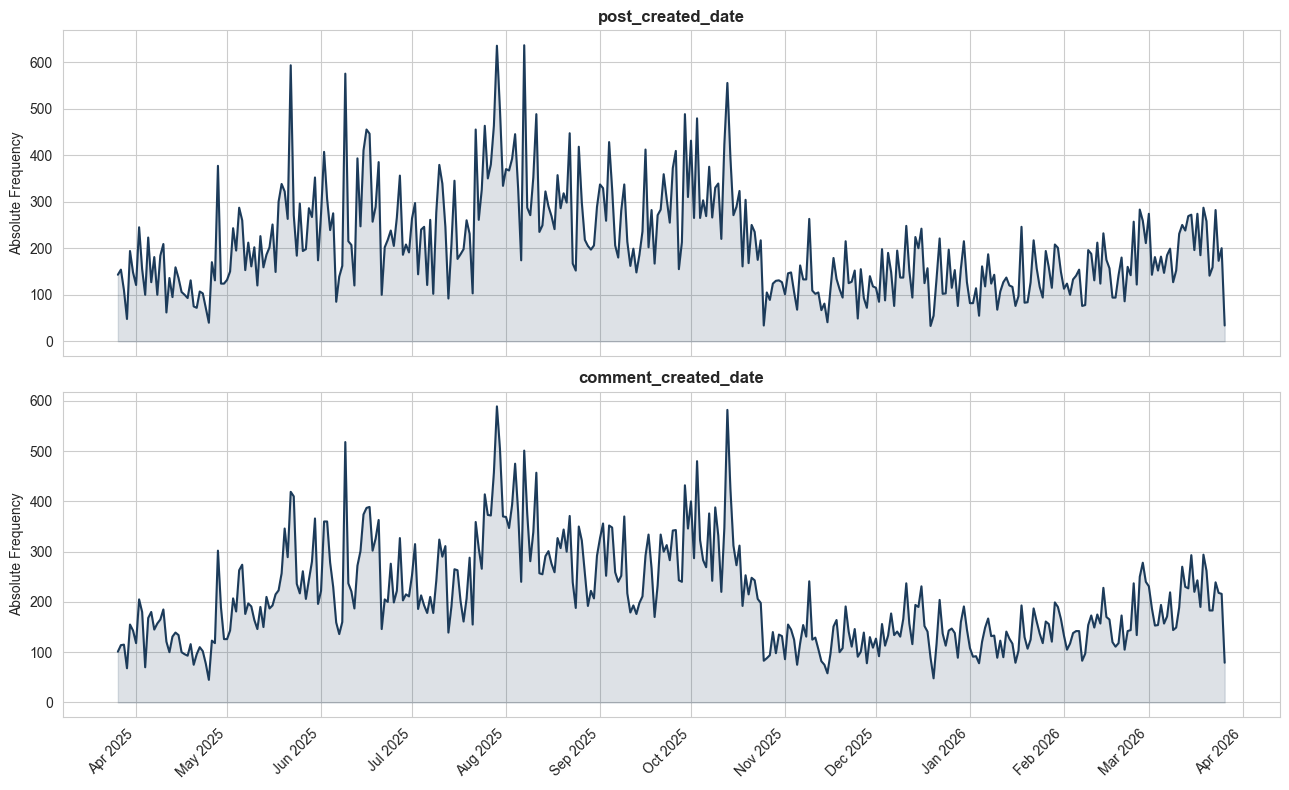

In [8]:
fig, axes = plt.subplots(len(date_cols), 1, figsize=(13, 4 * len(date_cols)), sharex=True)

for ax, col in zip(axes, date_cols):
    daily = (
        processed_data
        .with_columns(pl.col(col).dt.truncate("1d").alias("day"))
        .group_by("day")
        .agg(pl.len().alias("count"))
        .sort("day")
    )

    days   = daily["day"].to_list()
    counts = daily["count"].to_list()

    ax.plot(days, counts, color="#1C3B5A", linewidth=1.5)
    ax.fill_between(days, counts, alpha=0.15, color="#1C3B5A")
    ax.set_title(col, fontweight="bold")
    ax.set_ylabel("Absolute Frequency")

axes[-1].xaxis.set_major_locator(mdates.MonthLocator())
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.xticks(rotation=45, ha="right")

plt.tight_layout()

plot_file_name = 'time_variables_plot.png'
plot_save_path = os.path.join(results_dir, plot_file_name)
plt.savefig(plot_save_path, dpi=300, bbox_inches="tight")

plt.show()

In [9]:
processed_data['extraction_time'].unique()

extraction_time
"datetime[μs, UTC]"
2026-03-26 10:09:05.123482 UTC


### Query variables

In [10]:
query_cols = [
    'extraction_query',
    'extraction_sort',
    'post_subreddit'
]

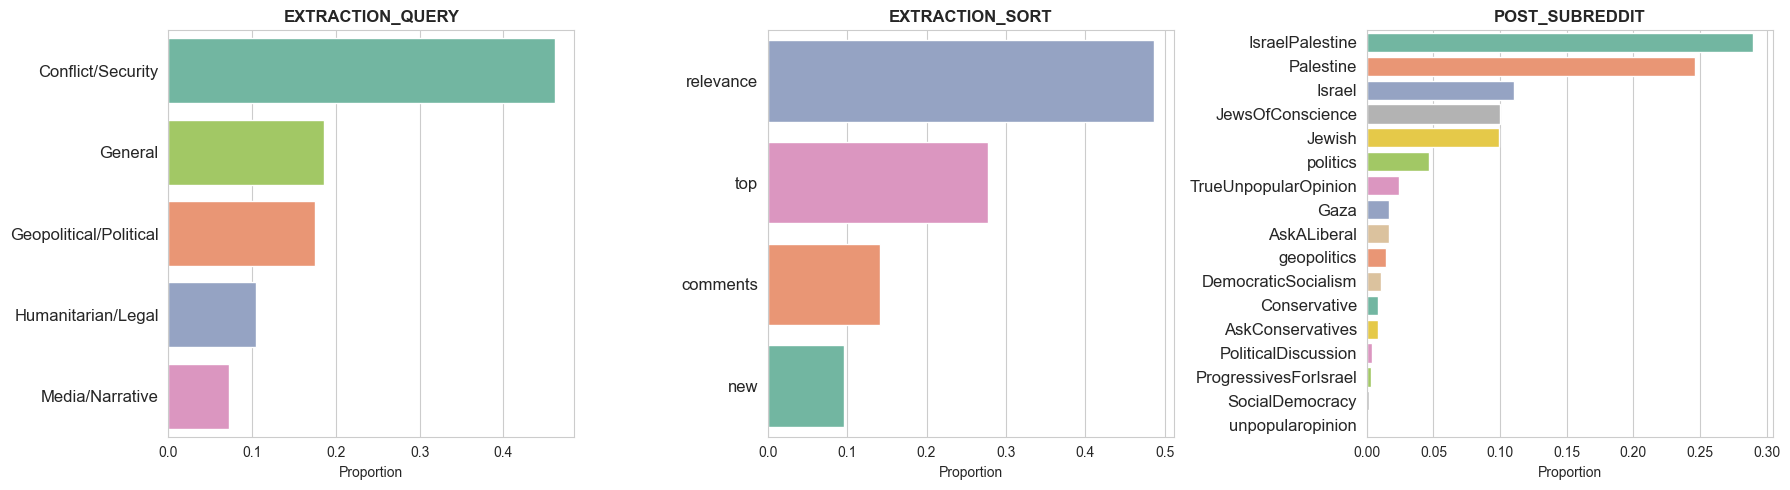

In [11]:
plot_file_name = 'query_variables_plot.png'
plot_save_path = os.path.join(results_dir, plot_file_name)

plot_cat_distribution(
    df = processed_data,
    cat_cols = query_cols,
    x_rotation = 90,
    order=True,
    orient="h", 
    max_cols=3,
    save_path=plot_save_path
)

### Reddit Scores

In [12]:
reddit_scores = [
    'post_score',
    'post_upvote_ratio',
    'post_num_comments',
    'comment_score'
]

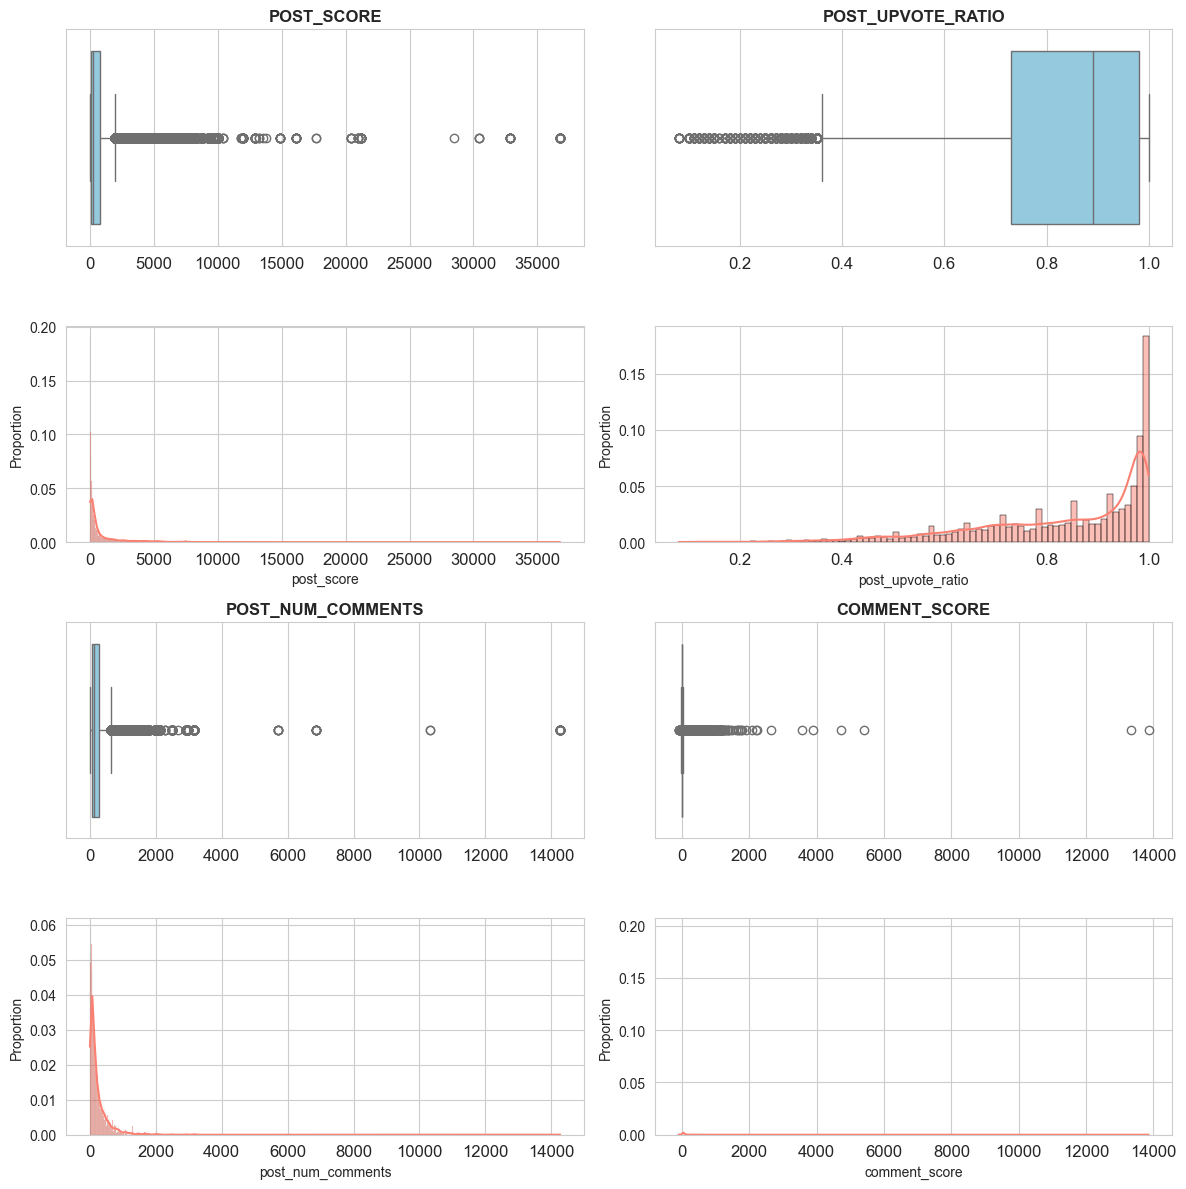

In [13]:
plot_file_name = 'reddit_scores_plot.png'
plot_save_path = os.path.join(results_dir, plot_file_name)

plot_quant_distribution(
    df = processed_data,
    quant_cols = reddit_scores,
    max_cols=2,
    save_path=plot_save_path
)

### Discursive Scores

In [ ]:
discursive_quant_scores = [
    'argument_quality_score',
    'political_stance_score',
    'sentiment_score'
]

discursive_cat_scores = [
    'content_relevance_score',
    'discourse_tone_score_label',
    'dominant_frame_score_label',
    'argument_quality_score_label',
    'sentiment_score_label',
    'political_stance_score_label'
]

association_var_types = {
    'sentiment_score': 'continuous',
    'political_stance_score': 'ordinal' ,
    'argument_quality_score': 'ordinal', 
    'discourse_tone_score': 'nominal', 
    'dominant_frame_score': 'nominal', 
}

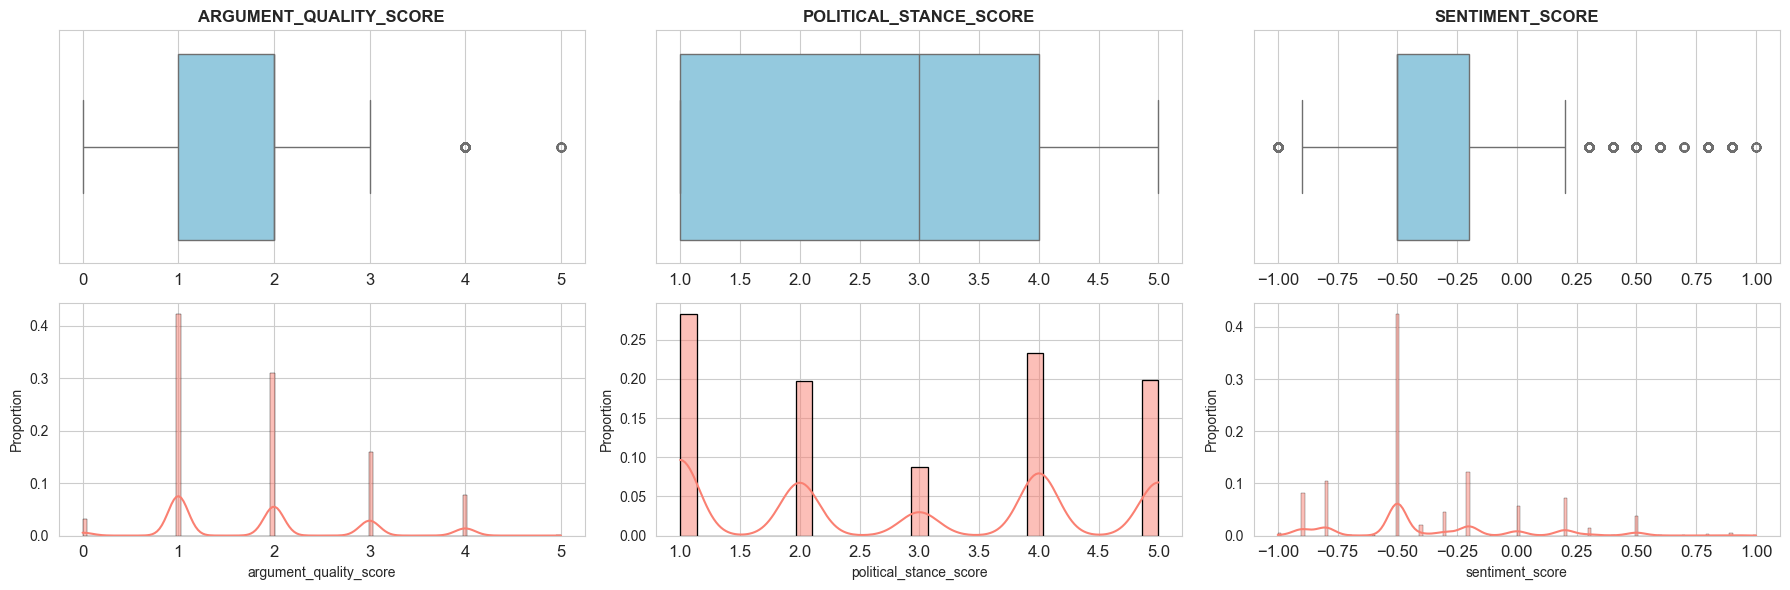

In [15]:
plot_file_name = 'discursive_quant_scores_plot.png'
plot_save_path = os.path.join(results_dir, plot_file_name)

plot_quant_distribution(
    df = processed_data,
    quant_cols = discursive_quant_scores,
    max_cols=3,
    save_path=plot_save_path
)

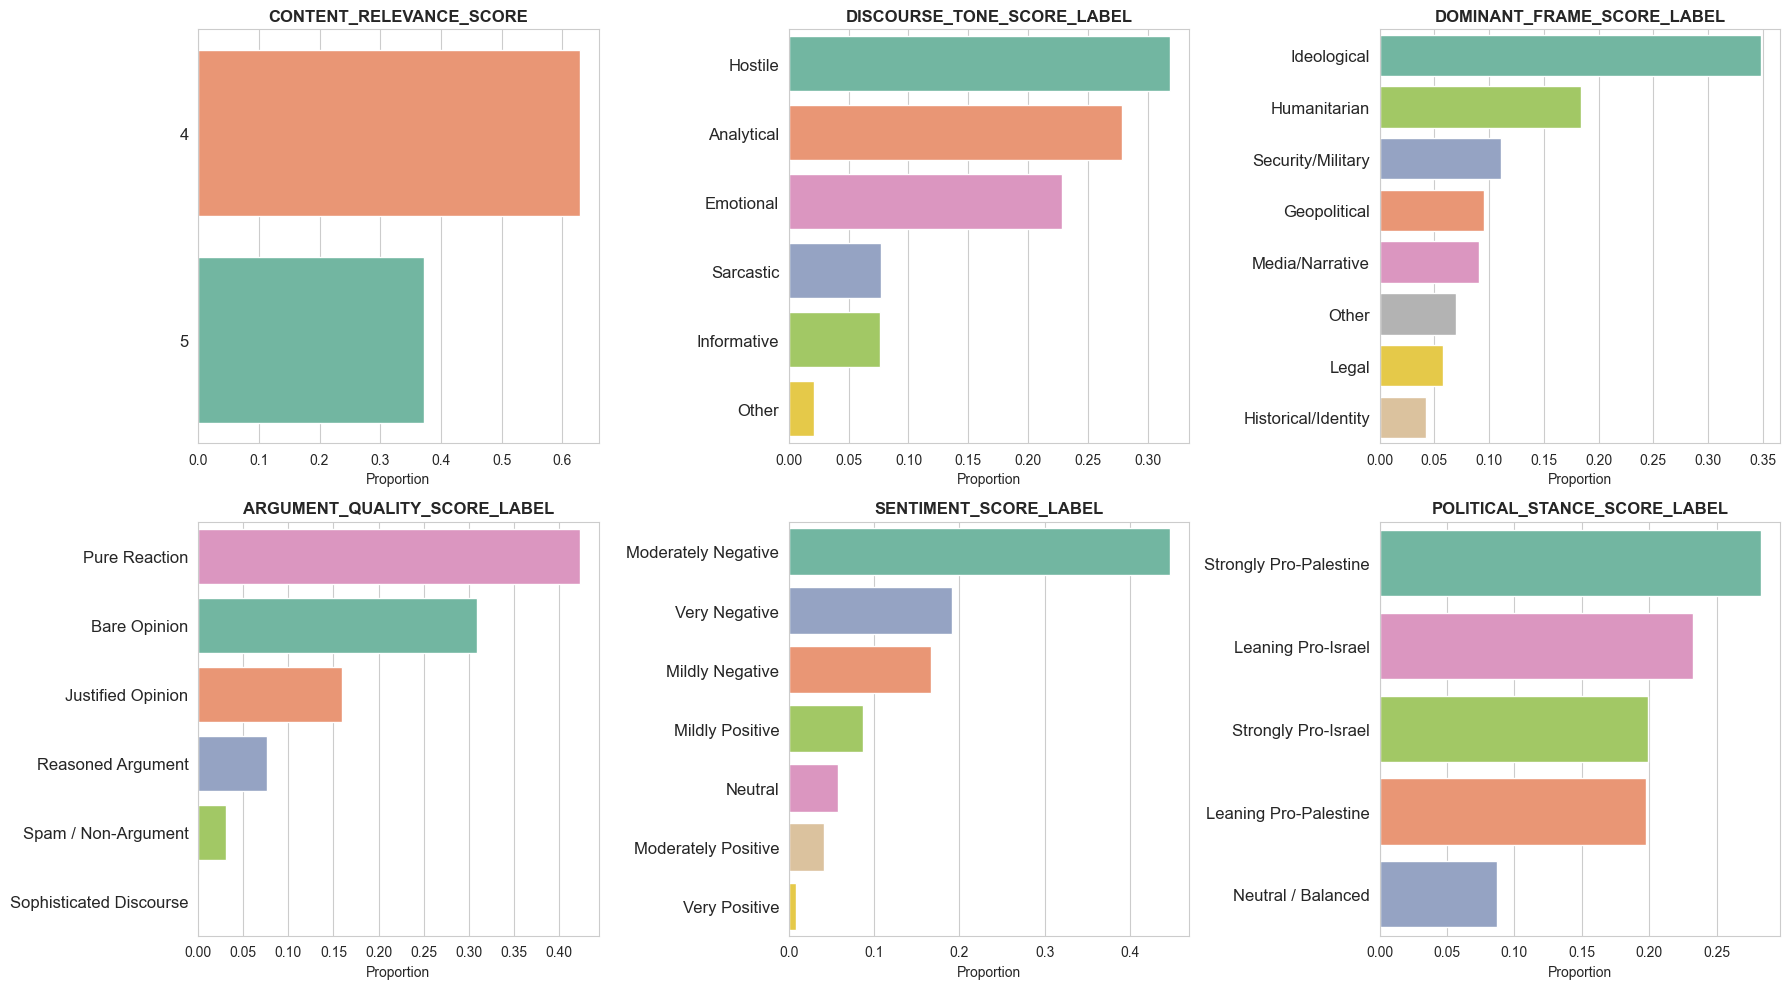

In [16]:
plot_file_name = 'discursive_cat_scores_plot.png'
plot_save_path = os.path.join(results_dir, plot_file_name)

plot_cat_distribution(
    df = processed_data,
    cat_cols = discursive_cat_scores,
    x_rotation = 90,
    order=True,
    orient="h", 
    max_cols=3,
    save_path=plot_save_path
)

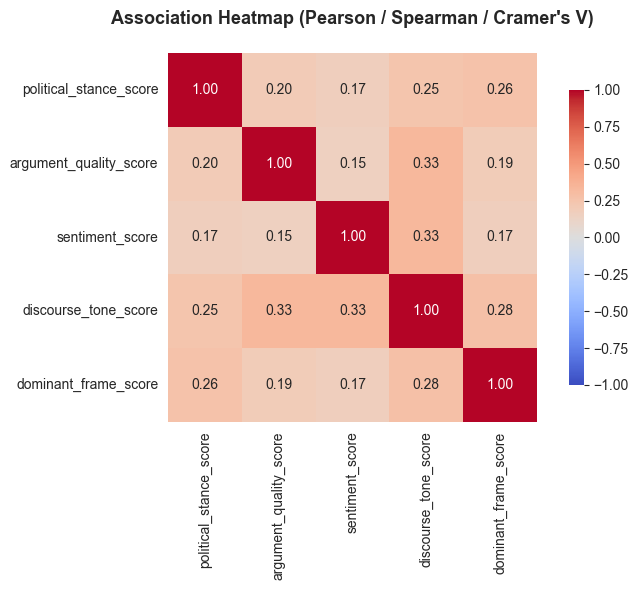

In [19]:
plot_mixed_association_heatmap(
    df=processed_data,
    var_types=association_var_types,
    title="Association Heatmap (Pearson / Spearman / Cramer's V)\n"
)